# 1. A *Plato* catalogue of AGNs

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from astropy.coordinates import SkyCoord
from ipywidgets import *
from tqdm import tqdm
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

# PlatoSim libraries
# import platosim.smbhb     as bh
import platosim.slurm     as sm
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [3]:
# Paths to where data is stored
hdir = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles/data_picsim'
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
idir = path / 'input'
ddir = path / 'data'
sdir = path / 'simulations'
fdir = path / 'figures'

---
## 1. Quasar PLATO-Gaia DR3 catalogue
---

The catalogues presented in this section were generated using `picsim`:

```
python picsim.py --vizier LOPS1 --gaia_quasar --mag_max 19 --project smbhb
python picsim.py --vizier LOPN1 --gaia_quasar --mag_max 19 --project smbhb
```

In [4]:
# Load catalogues and merge to one
ds = pd.read_feather(idir / 'starcat_GaiaDR3_LOPS2.ftr')
dn = pd.read_feather(idir / 'starcat_GaiaDR3_LOPN1.ftr')
df = pd.concat([ds, dn])

#-------------- delete upon new download of LOPS2
Pmag = df.Pmag
ncam = df.ncams  # Insert later
df = df.drop(columns=['source_gaia', 'ncams', 'Pmag'])
df.insert(0, 'ncam', ncam)
df.insert(5, 'Pmag', Pmag)
#------------------

# Number of objects
df.shape[0], df.columns

(20058,
 Index(['ncam', 'source_gaia_dr3', 'ra', 'dec', 'l', 'Pmag', 'b', 'Gmag',
        'BP_RP', 'Ag', 'plx', 'plx_err', 'pm', 'pmra', 'pmra_error', 'pmdec',
        'pmdec_error', 'ruwe', 'class_name', 'p_quasar', 'agn_score', 'qso_var',
        'qso_non', 'host_galaxy', 'z', 'z_err'],
       dtype='object'))

### 1.0. General cuts

In [5]:
# Start make some general cuts
dt0 = df[(df.class_name == 'AGN') & 
         (df. p_quasar > 0.999) & 
         (df.z > 0.09) & 
         (df.z_err < 0.05)]

# Sort after P magnitude
dt0 = dt0.sort_values(by=['ncam', 'Pmag'])

# Convert to percentage
dt0.p_quasar *= 100

# Number of objects
dt0.shape[0]

12985

### 1.1. Proper motion cut (Storey-Fisher+2024)

In [6]:
# Define decontamination line
G_line = np.linspace(5, 19, 100)
mu_line = 10**(0.4*(G_line - 18.25))

# Mark outliers
mu = 10**(0.4*(dt0.Gmag - 18.25))
do1 = dt0[(dt0.pm > mu)]
dt1 = dt0[(dt0.pm < mu)]

# Number of objects
dt1.shape[0]

12973

<IPython.core.display.Javascript object>


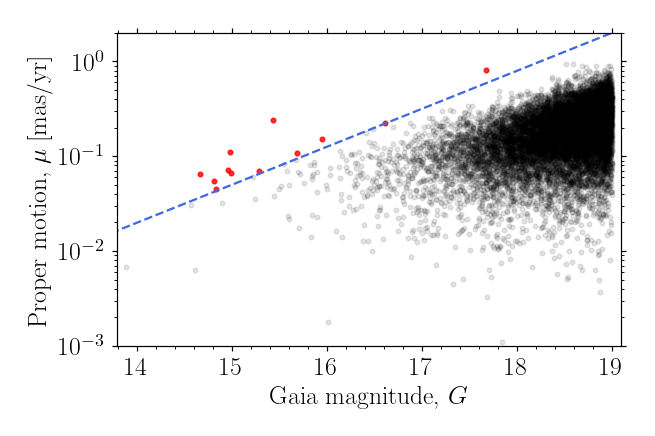

In [7]:
# Plot decontamination
fig = plt.figure(figsize=(6,4))
plt.plot(dt1.Gmag, dt1.pm, '.', c='k', alpha=0.1)
plt.plot(do1.Gmag, do1.pm, '.', c='r', alpha=0.8)
plt.plot(G_line, mu_line, '--', c='royalblue')
plt.xlabel(r'Gaia magnitude, $G$')
plt.ylabel(r'Proper motion, $\mu$ [mas/yr]')
plt.yscale('log')
plt.xlim(min(dt1.Gmag)-0.1, max(dt1.Gmag)+0.1)
plt.ylim(1e-3, 2e0)
plt.tight_layout();

### 1.2. Astrometric fidelity cut (Rubizki+2022)

In [8]:
# # Download (from a terminal) the fidelity_v2 to remove stars with spurious parallaxes:
# # curl -O http://vo.ari.uni-heidelberg.de/gedr3spur/dump.txt.gz
# # This catalogue has a fidelity for 1,467,744,800 stars.

# # Load fidelity_v2 to remove stars with spurious parallaxes
# dx = pd.read_csv(f"{idir}/dump.txt", sep='\t', chunksize=1000000, 
#                  names=["gaiaDR3", "fidelity", "a", "b", "c", "d", "e", "f", "g", "h", "i"]) 

# # Match in chunks since this file is huge!
# dx1 = pd.DataFrame()
# i = 0 
# for dx_i in tqdm(dx, bar_format=ut.tqdmBar()): 
    
#     # Attempt to find star matching our catalogue
# #     dx0 = dx_i.loc[dx_i['gaiaDR3'].isin(df.gaiaDR3)]
# #     print(dx_i.iloc[:,:2])
    
#     # Attempt to find stars we want to discard
#     dx0 = dx_i[dx_i.fidelity < 0.75]
#     dx0 = dx0.iloc[:,:2]
#     dx1 = pd.concat([dx1, dx0])
    
# #     i += 1
# #     if i == 100:
# #         break

# df0 = df.loc[:10]
# dx2.gaiaDR3.loc[0] = df0.gaiaDR3.loc[0]
# dx2.loc[dx2.gaiaDR3.isin(df0.gaiaDR3)]

# dx2.loc[dx2.gaiaDR3.isin(df.gaiaDR3)]
# 
# dex = df.gaiaDR3.isin(dx1.gaiaDR3)
# dx1
dt2 = dt1

### 1.3. QSO probability cut (Butler&Bloom,2011)

In [9]:
# Remove sources below black line above
do3 = dt2
def y(x): return x 
dt3 = dt2[(10**dt2.qso_non > 2.5) & (dt2.qso_non > y(dt2.qso_var))]

# Number of objects
dt3.shape[0]

12395

<IPython.core.display.Javascript object>


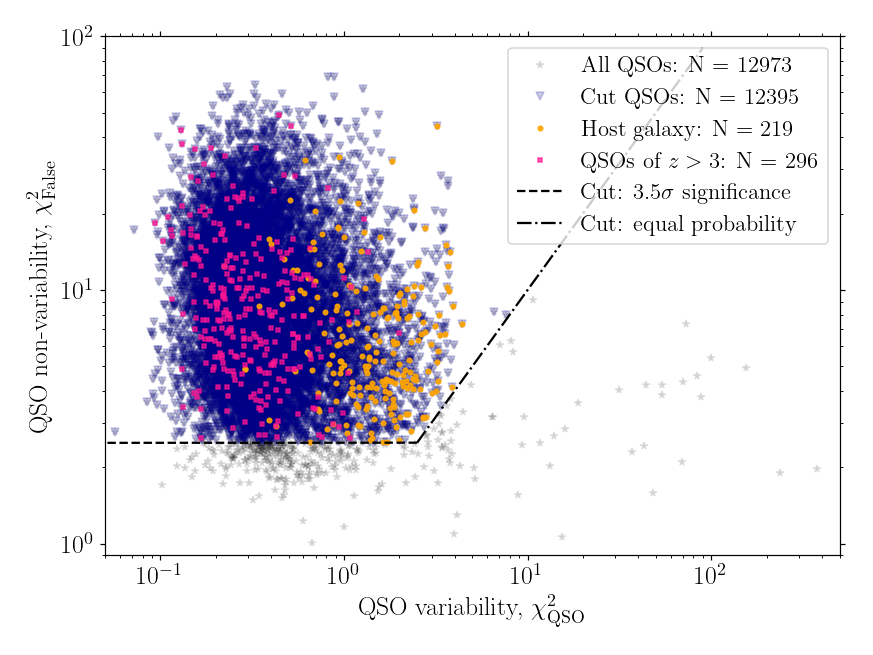

In [10]:
# Check how many of the AGNs that has a confirmed host galaxy
dh3 = dt3[(dt3.host_galaxy == True)]

# All quasar above z > 3
dz3 = dt3[dt3.z > 3]

# Plot diagnostic diagram of Butler and Bloom (2011)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(10**do3.qso_var, 10**do3.qso_non, '*', c='k',        alpha=0.1, ms=5, label=f'All QSOs: N = {do3.shape[0]}')
ax.plot(10**dt3.qso_var, 10**dt3.qso_non, 'v', c='darkblue', alpha=0.2, ms=5, label=f'Cut QSOs: N = {dt3.shape[0]}')
ax.plot(10**dh3.qso_var, 10**dh3.qso_non, '.', c='orange',   alpha=0.9,       label=f'Host galaxy: N = {dh3.shape[0]}')
ax.plot(10**dz3.qso_var, 10**dz3.qso_non, 's', c='deeppink', alpha=0.7, ms=3, label=r'QSOs of $z>3$: ' + f'N = {dz3.shape[0]}')
ax.plot([0, 2.5], [1, 2.5],         '--', c='k', label=r'Cut: 3.5$\sigma$ significance')
ax.plot([2.5, 90], [y(2.5), y(90)], '-.', c='k', label='Cut: equal probability')
ax.set_xlabel(r'QSO variability, $\chi_{\rm QSO}^2$')
ax.set_ylabel(r'QSO non-variability, $\chi_{\rm False}^2$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(5e-2, 5e2)
ax.set_ylim(0.9, 100)
ax.legend()
plt.tight_layout();
# fig.savefig(f'{fdir}/variability_QSO.png', bbox_inches='tight', dpi=300)

### 1.4. Cross-match with Quaia catalogue (Storey-Fisher+2024)

In [11]:
# Load Quaia catalogue
filename = f'{ddir}/quaia_G20.5.fits'
data = Table.read(filename, format='fits')
df_quaia = data.to_pandas()
df_quaia.head()

,source_id,unwise_objid,redshift_quaia,redshift_quaia_err,ra,dec,l,b,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,mag_w1_vg,mag_w2_vg,pm,pmra,pmdec,pmra_error,pmdec_error
0,6459630980096,b'0453p000o0014479',0.416867,0.060812,44.910498,0.189649,176.659434,-48.835164,20.173105,20.200150,18.871586,14.774343,13.923867,0.383797,0.217806,-0.316007,0.679419,0.608799
1,10892037246720,b'0453p000o0015876',1.736468,0.096594,45.188575,0.282424,176.851544,-48.570856,18.787239,19.080688,18.240915,15.219950,13.868094,0.155406,-0.098037,-0.120580,0.257395,0.223107
2,15839839588736,b'0453p000o0017020',1.513049,0.063187,45.189480,0.359195,176.769129,-48.516842,18.888464,19.171280,18.509371,15.317786,14.013617,0.448925,-0.316088,0.318781,0.360595,0.326582
3,19275813399552,b'0453p000o0024506',2.422632,0.055260,44.835496,0.237432,176.527928,-48.855622,20.330523,20.320410,19.841410,17.273508,16.396996,1.085342,1.062588,0.221073,0.739487,0.625105
4,22780506725760,b'0453p000o0016209',2.852854,0.076640,44.799365,0.303557,176.417664,-48.835309,19.218422,19.486340,18.814501,16.027142,15.041919,0.523211,0.168237,0.495425,0.361439,0.269473


In [12]:
# Match catalogues
dx4 = df_quaia
dt4 = dt3[dt3['source_gaia_dr3'].isin(dx4['source_id'])].sort_values(by=['source_gaia_dr3']).reset_index(drop=True)
dx4 = dx4[dx4['source_id'].isin(dt4['source_gaia_dr3'])].sort_values(by=['source_id']).reset_index(drop=True)

# Replace redshift from Quaia
dt4['z']     = dx4.redshift_quaia
dt4['z_err'] = dx4.redshift_quaia_err

# Sort after P magnitude
dt4 = dt4.sort_values(by=['ncam', 'Gmag'])

### 1.6 Assemble final catalogue

In [13]:
# Store data frames
dt = dt4
# dn = dn4
# ds = ds4

# Sperate LOPS2 and LOPN1
ds = dt[dt.b < 0]
dn = dt[dt.b > 0]

# Seperate camera visibility
dt06 = dt[dt.ncam ==  6]
dt12 = dt[dt.ncam == 12]
dt18 = dt[dt.ncam == 18]
dt24 = dt[dt.ncam == 24]

# Store global dfs
dt = dt.reset_index(drop=True)
ds = dt[dt.b < 0].sort_values(by=['ncam', 'Pmag']).reset_index(drop=True)
dn = dt[dt.b > 0].sort_values(by=['ncam', 'Pmag']).reset_index(drop=True)
dt.head()

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,pmdec_error,ruwe,class_name,p_quasar,agn_score,qso_var,qso_non,host_galaxy,z,z_err
0,6,1331085410995536640,248.004632,37.630550,60.342100,15.656564,42.939346,15.840618,0.579854,1.8440,...,0.036347,1.043414,AGN,100.0,0.403316,-0.316279,0.683840,False,1.476276,0.446821
1,6,4828236384002699520,57.747604,-52.676254,263.037832,15.658949,-48.152123,15.851448,0.611596,1.8750,...,0.039195,1.057984,AGN,100.0,0.588843,-0.438903,0.687227,False,1.542538,0.402480
2,6,1646883258074187520,242.960135,69.737907,103.023904,15.855906,38.716636,16.026461,0.530438,1.6903,...,0.043050,0.924078,AGN,100.0,0.289868,0.099042,0.419567,False,1.021370,0.296468
3,6,1637030740536551296,256.509188,68.960115,99.934050,15.865224,34.569524,16.031271,0.514276,1.3885,...,0.044007,1.073094,AGN,100.0,0.317068,-0.351945,0.463984,False,0.451021,0.164616
4,6,1326101290427211904,246.530178,33.987571,55.200032,15.979334,43.794674,16.138632,0.490378,1.2550,...,0.039655,1.063018,AGN,100.0,0.142509,0.642049,0.867423,True,0.291247,0.121641


<IPython.core.display.Javascript object>


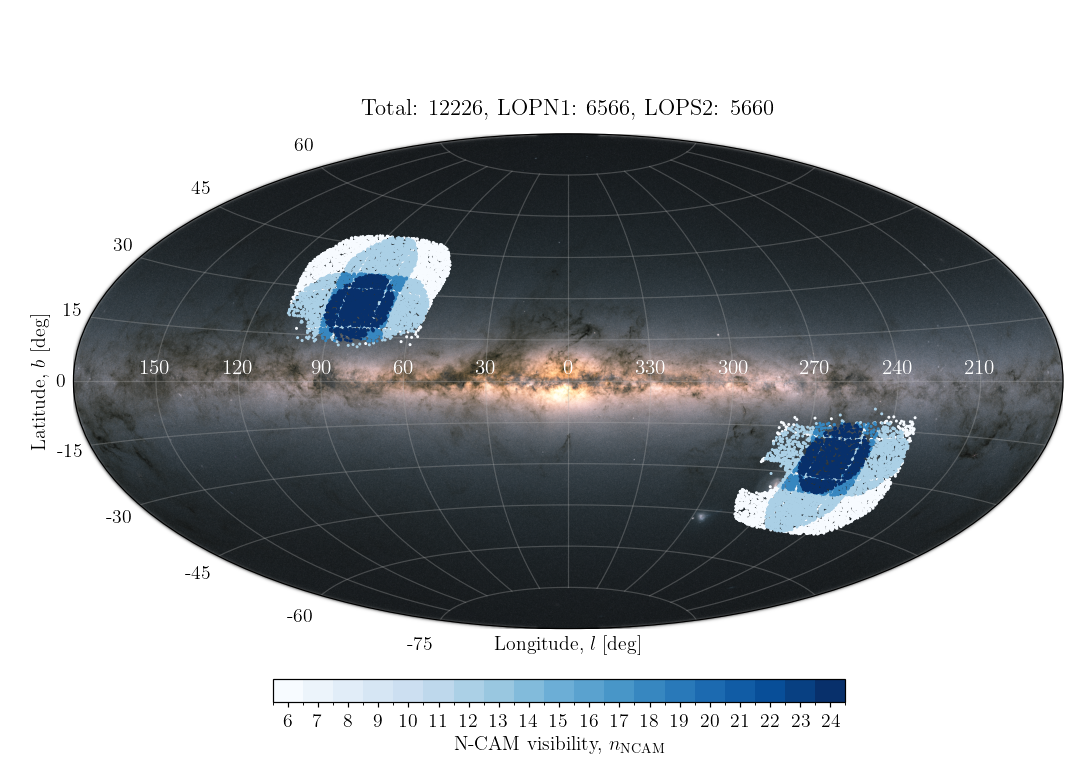

In [14]:
# Show matching sources in sky
fig, ax = pt.plot_aitoff(dt)

<IPython.core.display.Javascript object>


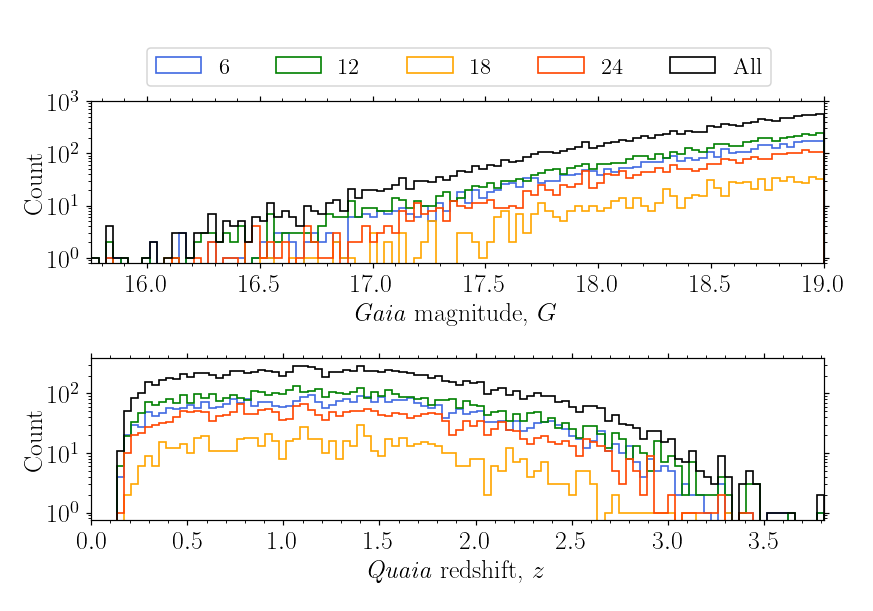

In [15]:
# Plot histograms
lw, N = 1.1, 100
c = ['royalblue', 'green', 'orange', 'orangered', 'k']
# c = ['skyblue', 'deepskyblue', 'dodgerblue', 'royalblue', 'k']
fig = plt.figure(figsize=(8,2.8*2))

ax1 = plt.subplot(2, 1, 1)
G_min, G_max = dt4.Gmag.min(), dt4.Gmag.max()
ax1.hist(dt06.Gmag, bins=N, range=(G_min, G_max), histtype='step', ec=c[0], lw=lw, label='6')
ax1.hist(dt12.Gmag, bins=N, range=(G_min, G_max), histtype='step', ec=c[1], lw=lw, label='12')
ax1.hist(dt18.Gmag, bins=N, range=(G_min, G_max), histtype='step', ec=c[2], lw=lw, label='18')
ax1.hist(dt24.Gmag, bins=N, range=(G_min, G_max), histtype='step', ec=c[3], lw=lw, label='24')
ax1.hist(dt.Gmag,   bins=N, range=(G_min, G_max), histtype='step', ec=c[4], lw=lw, label='All')
ax1.set_xlabel(r'\textit{Gaia} magnitude, $G$')
ax1.set_xlim(G_min, 19)
ax1.set_ylim(0.8, 1000)
ax1.legend(loc='upper left', bbox_to_anchor=(0.06, 1.4), ncols=5)

ax2 = plt.subplot(2, 1, 2)
z_min, z_max = dt4.z.min(), dt4.z.max()
ax2.hist(dt06.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[0], lw=lw)
ax2.hist(dt12.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[1], lw=lw)
ax2.hist(dt18.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[2], lw=lw)
ax2.hist(dt24.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[3], lw=lw)
ax2.hist(dt.z,   bins=N, range=(z_min, z_max), histtype='step', ec=c[4], lw=lw)
ax2.set_xlabel(r'\textit{Quaia} redshift, $z$')
ax2.set_xlim(0, z_max)

for ax in [ax1, ax2]:
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    ax.get_yaxis().set_label_coords(-0.06, 0.5)
plt.tight_layout()
# fig.savefig(f'{fdir}/historgram_quasars.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


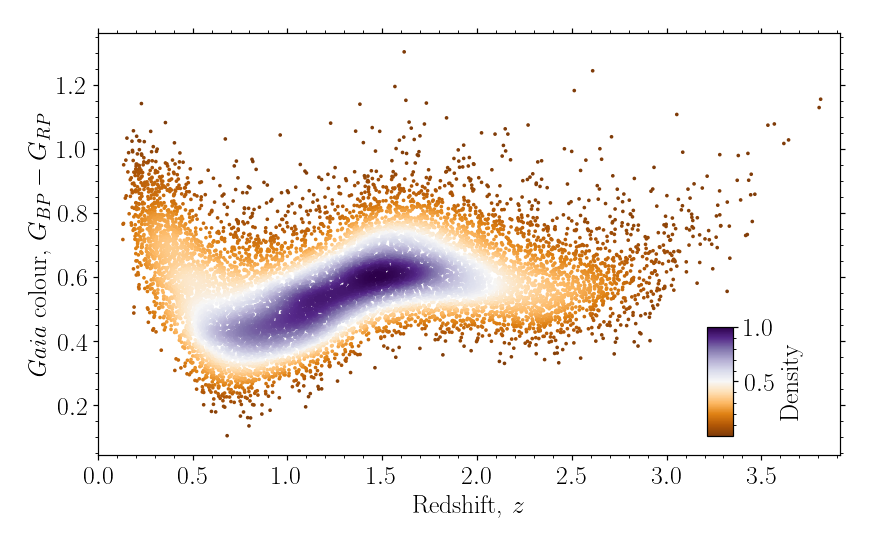

In [16]:
# Plot redshift-colour correlation
x, y, z, dex = ut.sortAfterDensity(dt.z.to_numpy(), dt.BP_RP.to_numpy())
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
im = ax.scatter(x, y, c=z/np.max(z), s=2, cmap="PuOr")
cbarax = fig.add_axes([0.81, 0.2, 0.03, 0.2])
cbar = plt.colorbar(im, orientation='vertical', cax=cbarax)
cbar.set_label('Density')
ax.set_ylabel(r'\textit{Gaia} colour, $G_{BP} - G_{RP}$')
ax.set_xlabel(r'Redshift, $z$')
ax.set_xlim(0, z_max+0.1)
plt.tight_layout()
# fig.savefig(f'{fdir}/correlation_redshift_vs_colour.png', bbox_inches='tight', dpi=200)

#### *Limiting magnitude*

In [17]:
dx = dt.sort_values(by=['Pmag'], ascending=False)

In [18]:
# Number of sources below 18
dx[(dx.b < 0) & (dx.Pmag < 18)].shape[0], dx[(dx.b > 0) & (dx.Pmag < 18)].shape[0]

(1452, 1732)

In [19]:
# Number of sources below 17.5
dx[(dx.b < 0) & (dx.Pmag < 17.5)].shape[0], dx[(dx.b > 0) & (dx.Pmag < 17.5)].shape[0]

(494, 600)

In [20]:
# Number of targets below 17.0 mag
dx[(dx.b < 0) & (dx.Pmag < 17)].shape[0], dx[(dx.b > 0) & (dx.Pmag < 17)].shape[0]

(170, 177)

In [21]:
# Select limited magnitude
dx = dx[dx.Pmag < 17.5]

<IPython.core.display.Javascript object>


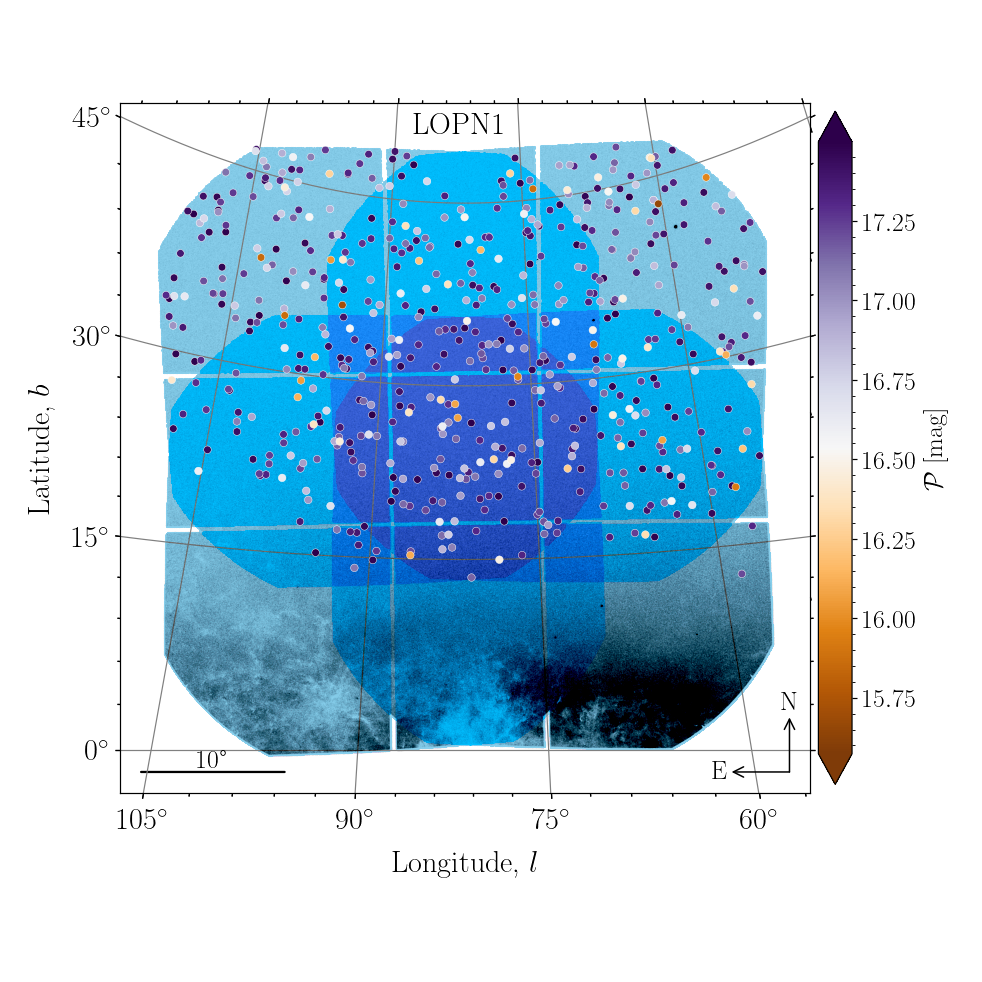

Text(340, 670, 'LOPN1')

In [24]:
fig, ax = pt.plotPlatoFOV('LOPN1', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=100, lw=0.3, ec='w',
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPN1', horizontalalignment='center', verticalalignment='center', fontsize=20)
# fig.savefig(fdir / f'skymap_quasars_LOPN1_mag175.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


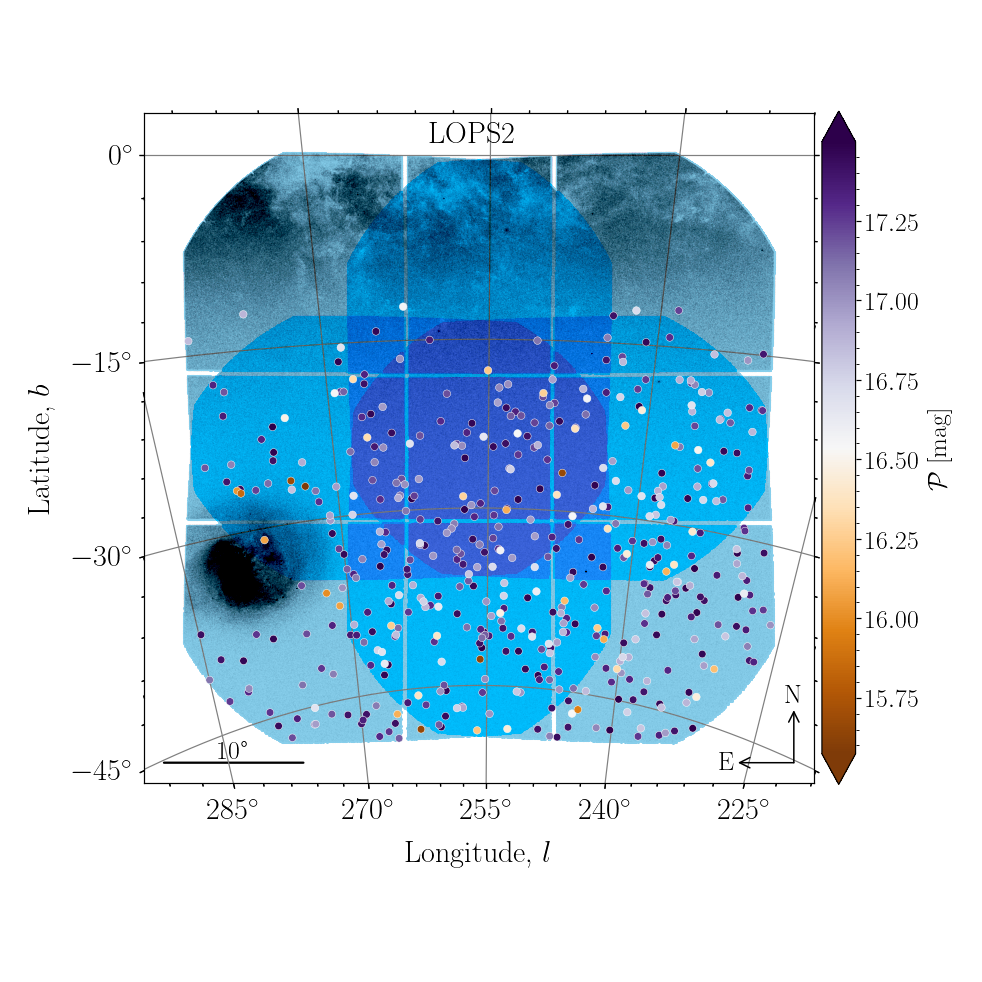

Text(340, 670, 'LOPS2')

In [23]:
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=100, lw=0.3, ec='w',
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPS2', horizontalalignment='center', verticalalignment='center', fontsize=20)
# fig.savefig(fdir / 'skymap_quasars_LOPS2_mag175.png', bbox_inches='tight', dpi=200)

### Check overlap with *Roman*

In [25]:
ra = [241, 243, 245, 243]
dec = [55, 56.3, 55, 53.8] 

<IPython.core.display.Javascript object>


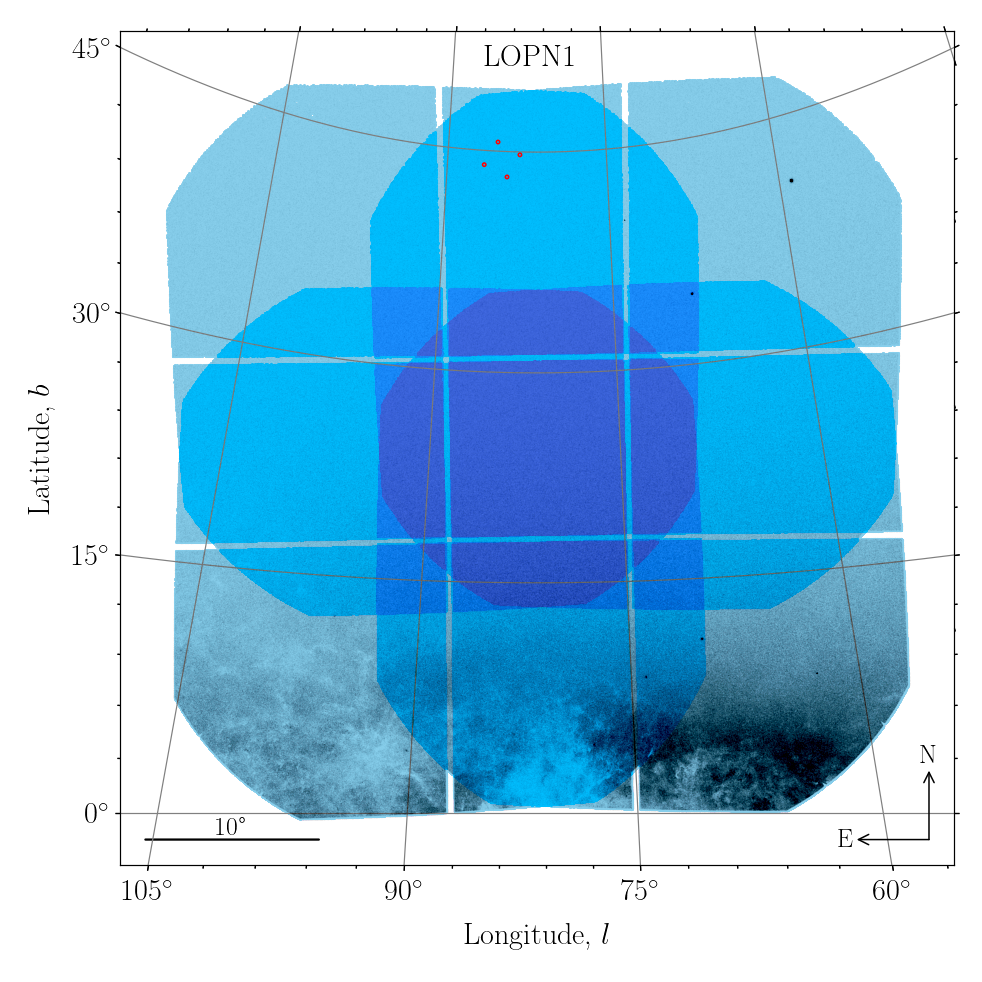

In [27]:
fig, ax = pt.plotPlatoFOV('LOPN1', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=ra, decStars=dec, c=None, s=500, lw=1, ec='r',
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPN1', horizontalalignment='center', verticalalignment='center', fontsize=20);
# fig.savefig(fdir / f'skymap_quasars_LOPN1_mag175.png', bbox_inches='tight', dpi=200)

In [28]:
ra  = [62, 63.5, 66, 63.5]
dec = [-47.7, -46.1, -47.7, -49.2] 

<IPython.core.display.Javascript object>


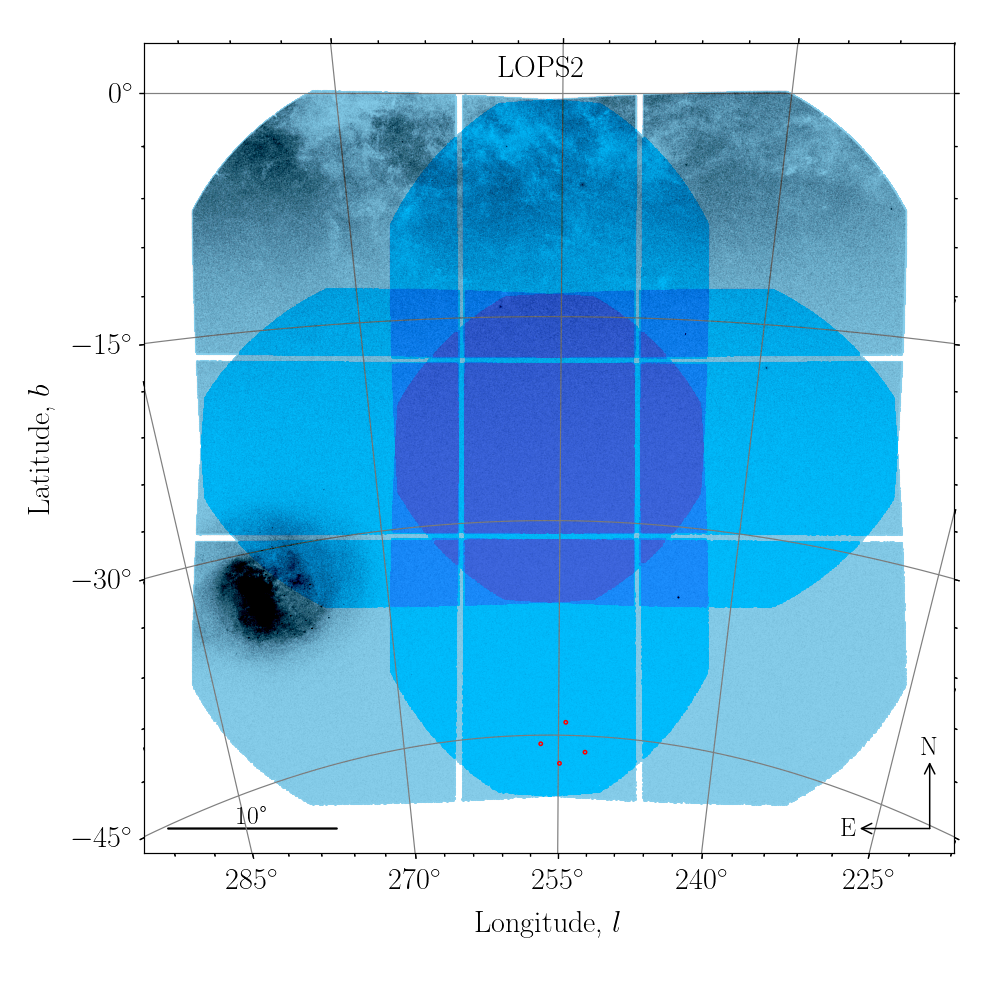

Text(340, 670, 'LOPS2')

In [29]:
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=ra, decStars=dec, c=None, s=1000, lw=1, ec='r',
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPS2', horizontalalignment='center', verticalalignment='center', fontsize=20)
# fig.savefig(fdir / 'skymap_quasars_LOPS2_mag175.png', bbox_inches='tight', dpi=200)

### 1.6 Save PLATO catalogue for NSR simulations

In [52]:
# # Search for stars wihtin 60 arcsec (3 pixels)
# radius = 60

In [16]:
# # Fetch contaminants of LOPS2 targets
# n = ds.shape[0]
# for i in tqdm(range(n), bar_format=ut.tqdmBar()):
#     # Query cone around each target
#     di = ds.loc[i]
#     dc = sq.gaiaQueryCone(di.ra, di.dec, radius=radius/3600, flag_stellar=True)
#     # Rename after target and keep contaminants
#     dc.source_gaia_dr3 = [di.source_gaia_dr3] * dc.shape[0]
#     if (dc.source_gaia_dr3 == di.source_gaia_dr3).any():
#         dc = dc[dc.dis != 0]
#     # Add catalogues together
#     if i == 0:
#         ds_con = dc
#     else:
#         ds_con = pd.concat([ds_con, dc])

In [17]:
# # Save contaminant catalogue for LOPS2
# ds_con = ds_con.reset_index(drop=True)
# ds_con.insert(6, 'Pmag', ut.passbandConversionG2P(ds_con.Gmag, ds_con.BP_RP))
# ds_con.to_feather(f'{idir}/starcat_PlatoCS_QSO_LOPS2_contaminants.ftr')

In [ ]:
# # Fetch contaminants of LOPN1 targets
# n = dn.shape[0]
# for i in tqdm(range(n), bar_format=ut.tqdmBar()):
#     # Query cone around each target
#     di = dn.loc[i]
#     dc = sq.gaiaQueryCone(di.ra, di.dec, radius=radius/3600, flag_stellar=True)
#     # Rename after target and keep contaminants
#     dc.source_gaia_dr3 = [di.source_gaia_dr3] * dc.shape[0]
#     if (dc.source_gaia_dr3 == di.source_gaia_dr3).any():
#         dc = dc[dc.dis != 0]
#     # Add catalogues together
#     if i == 0:
#         dn_con = dc
#     else:
#         dn_con = pd.concat([dn_con, dc])

In [ ]:
# # Save contaminant catalogue for LOPN1
# dn_con = dn_con.reset_index(drop=True)
# dn_con.insert(6, 'Pmag', ut.passbandConversionG2P(dn_con.Gmag, dn_con.BP_RP))
# dn_con.to_feather(f'{idir}/starcat_PlatoCS_QSO_LOPN1_contaminants.ftr')

In [ ]:
# # Generate SLURM paramterisations files
# sm.getParamFile(np.arange(1, ds.shape[0]), np.arange(1,5), cameras=None, quarters=None, fcam=False, ofile=f'{idir}/cluster_ncam_LOPS2.data');
# sm.getParamFile(np.arange(1, dn.shape[0]), np.arange(1,5), cameras=None, quarters=None, fcam=False, ofile=f'{idir}/cluster_ncam_LOPN1.data');

### 1.7. Add noise parameters to catalogue (NSR vs. G-mag)

We here present the noise budget of simulated light curves using the two generated catalogues from the previous section.

In [ ]:
# Define output file names
ofile_camera_LOPN1 = f'{sdir}/nsr/nsr_per_camera_LOPN1.ftr'
ofile_camera_LOPS2 = f'{sdir}/nsr/nsr_per_camera_LOPS2.ftr'
ofile_star_LOPN1 = f'{sdir}/nsr/nsr_per_star_LOPN1.ftr'
ofile_star_LOPS2 = f'{sdir}/nsr/nsr_per_star_LOPS2.ftr'

In [ ]:
# Fetch the NSR per camera and star
# lcs = LightCurve(f'{sdir}/nsr/LOPN1', 'multi')
# lcs.get_nsr_per_camera(ofile_camera_LOPN1, suffix='hdf5', quarter=1)
# lcs = LightCurve(f'{sdir}/nsr/LOPS2', 'multi')
# lcs.get_nsr_per_camera(ofile_camera_LOPS1, suffix='hdf5', quarter=1)
# lcs = LightCurve(f'{sdir}/nsr/LOPN1', 'multi')
# lcs.get_nsr_per_star(ofile_star_LOPN1, suffix='hdf5', quarter=1)
# lcs = LightCurve(f'{sdir}/nsr/LOPS2', 'multi')
# lcs.get_nsr_per_star(ofile_star_LOPS2, suffix='hdf5', quarter=1)

In [ ]:
# Load results
dn_camera = pd.read_feather(ofile_camera_LOPN1)
ds_camera = pd.read_feather(ofile_camera_LOPS2)
dn_star = pd.read_feather(ofile_star_LOPN1)
ds_star = pd.read_feather(ofile_star_LOPS2)

In [ ]:
# Add noise columns to LOPN1
dn['ncon'] = dn_star.ncon
dn['SPR']  = dn_star.SPR
dn['rOA']  = dn_star.rOA
dn['NSR']  = dn_star.NSR

# Add noise columns to LOPS2
ds['ncon'] = ds_star.ncon
ds['SPR']  = ds_star.SPR
ds['rOA']  = ds_star.rOA
ds['NSR']  = ds_star.NSR

# Combine catalogues and sort after N-CAM
dt = pd.concat([ds, dn]).sort_values(by=['ncam', 'Gmag']).reset_index(drop=True)
dt.head()

In [ ]:
# Save catalogue to avoid running section 1 again
ds.to_feather(idir / 'starcat_PlatoCS_QSO_LOPS2_targets.ftr')
dn.to_feather(idir / 'starcat_PlatoCS_QSO_LOPN1_targets.ftr')

#### *Plots for paper*

In [ ]:
# Investigate parameters
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

ax[0].hist(dt.SPR, bins=80)
ax[0].set_xlabel('SPR')
ax[0].set_ylabel('Counts')
ax[0].set_yscale('log')
ax[0].set_xlim(0, 1)

ax[1].hist(dt.ncon, bins=300)
ax[1].set_xlabel(r'$n_{\rm contaminants}$')
ax[1].set_yscale('log')
ax[1].set_xlim(0, 60)

ax[2].hist(dt.rOA, bins=80)
ax[2].set_xlabel(r'$\vartheta_{\rm OA}$ [deg]')
ax[2].set_xlim(7, 20)

plt.tight_layout();

In [ ]:
# Plot camera level NSR for LOPN1
col = 'rOA'
lim = 0.01
dx = dn_camera.sort_values(by=[col], ascending=False)
da = dx[dx.SPR > lim]
db = dx[dx.SPR < lim]
fig, ax = pt.plotNSRvsMagnitude(db, column=col, passband='P', 
                                show_ncam_noise_limits=1, 
                                legend='SMBHB', figsize=(9, 6))
ax.plot(da.mag, da.NSR, 'k.', alpha=0.1, zorder=-1)
ax.set_title('Noise budget at camera level')
ax.set_ylim(dx.NSR.min(), dx.NSR.max());

In [ ]:
# Plot camera level NSR for LOPS2
col = 'rOA'
lim = 0.01
dx = ds_camera
dx = dx.sort_values(by=[col], ascending=False)
da = dx[dx.SPR > lim]
db = dx[dx.SPR < lim]
fig, ax = pt.plotNSRvsMagnitude(db, column=col, passband='P', 
                                show_ncam_noise_limits=1, 
                                legend='SMBHB', figsize=(9, 6))
ax.plot(da.mag, da.NSR, 'k.', alpha=0.1, zorder=-1)
ax.set_title('Noise budget at camera level')
ax.set_ylim(dx.NSR.min(), dx.NSR.max());

In [ ]:
# Plot mission level NSR for LOPN1
col = 'ncam'
lim = 0.01
dx = dn_star
dx = dx.sort_values(by=[col], ascending=False)
da = dx[dx.SPR > lim]
db = dx[dx.SPR < lim]
fig, ax = pt.plotNSRvsMagnitude(db, column=col, passband='P', 
                                show_ncam_noise_limits=False,
                                figsize=(9, 6))
ax.plot(da.mag, da.NSR, 'k.', alpha=0.1, zorder=-1)
ax.set_title('Noise budget at mission level')
ax.set_ylim(dx.NSR.min(), dx.NSR.max());

In [ ]:
# Plot mission level NSR for LOPS2
col = 'ncam'
lim = 0.01
dx = ds_star
ds = dx.sort_values(by=[col], ascending=False)
db = dx[dx.SPR < lim]
da = dx[dx.SPR > lim]
fig, ax = pt.plotNSRvsMagnitude(db, column=col, passband='P',
                                show_ncam_noise_limits=False, 
                                figsize=(9, 6))
ax.plot(da.mag, da.NSR, 'k.', alpha=0.2, zorder=-1)
ax.set_title('Noise budget at mission level')
ax.set_ylim(dx.NSR.min(), dx.NSR.max());

#### *Combine plots above into a single figure for the paper* 

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9,6))
lim = 0.01
cmap = 'rainbow'
cmap = plt.cm.get_cmap(cmap)

# Load data and sort
col = 'rOA'
dn = pd.read_feather(f'{sdir}/nsr/nsr_per_camera_LOPN1.ftr')
ds = pd.read_feather(f'{sdir}/nsr/nsr_per_camera_LOPS2.ftr')
df = pd.concat([dn, ds]).sort_values(by=[col], ascending=False)
df.NSR /= 1e3
db = df[df.SPR < lim]
da = df[df.SPR > lim]
# Plot simulations
ax[0].plot(da.mag, da.NSR, 'ko', ms=1, alpha=0.05, zorder=-1)
im = ax[0].scatter(db.mag, db.NSR, s=3, alpha=1, zorder=1, c=db[col], cmap=cmap)
ticks = [0.8, 7, 14, 19.4]
cb = plt.colorbar(im, pad=0.01, ticks=ticks, location='top')
cb.set_label(r'$\vartheta_{\rm OA}$ [$^{\circ}$]')
# Plot noise curves        
mag = np.linspace(0, 20, 100)
noise_jitter = ut.getJitterNoiseLimitNSR(rms=0.04, tdur=3600, camType='normal') / 1e3
noise_photon = ut.getPhotonNoiseLimitNSR(mag, passband='P', ncam=1) / 1e3
noise_background = ut.getBackgroundNoiseLimitNSR(mag, passband='P', ncam=1) / 1e3
noise = np.sqrt(noise_jitter**2 + noise_photon**2 + noise_background**2)
ax[0].plot(mag, noise_photon, '-.', c='deeppink', lw=1.5, zorder=2, label='Photon noise')
ax[0].plot(mag, noise_background, ':', c='deeppink', lw=1.5, zorder=2, label='Sky/read noise')
ax[0].plot(mag, noise, '-', c='orange', lw=2,  zorder=2, label='Noise model')
# Settings
dx = (df.mag.max() - df.mag.min()) * 1e-2
ax[0].set_xlim(df.mag.min()-dx, df.mag.max()+dx)
ax[0].set_ylim(3e-1, 1e3)
ax[0].set_yscale('log')
ax[0].legend(loc='upper left')

# Load data and sort
col = 'ncam'
dn = pd.read_feather(f'{sdir}/nsr/nsr_per_star_LOPN1.ftr')
ds = pd.read_feather(f'{sdir}/nsr/nsr_per_star_LOPS2.ftr')
df = pd.concat([dn, ds]).sort_values(by=[col], ascending=False)
df.NSR /= 1e3
db = df[df.SPR < lim]
da = df[df.SPR > lim]
# Plot simulations
ax[1].plot(da.mag, da.NSR, 'ko', ms=2, alpha=0.05, zorder=-1)
im1 = ax[1].scatter(db.mag, db.NSR, s=3, alpha=1, zorder=1, c=db[col], cmap=cmap)
cbins = np.arange(db[col].min(), db[col].max()+2, 1)
ticks = np.array([1, 6, 12, 18, 24]) + 0.5 
norm  = pt.discretizeColorbar(cbins=cbins, cmap=cmap)
cb = plt.colorbar(im1, pad=0.01, spacing='proportional', location='top',
                  ticks=ticks, boundaries=cbins, format='%1i')
cb.set_label(r'$n_{\rm CAM}$')
cb.minorticks_off()
# Settings
dx = (df.mag.max() - df.mag.min()) * 1e-2
ax[1].set_xlim(df.mag.min()-dx, df.mag.max()+dx)
ax[1].set_ylim(1e-1, 1e2)
ax[1].set_yscale('log')

# Common settings
fig.text(0.5, 0.02, r'PLATO magnitude, $\mathcal{P}$', ha='center')
fig.text(0.04, 0.5, r'NSR [ppt h$^{-1/2}$]', va='center', rotation='vertical')
plt.subplots_adjust(hspace=0.1)
# fig.savefig(f'{fdir}/nsr_quasars.png', bbox_inches='tight', dpi=300)

---
## 2. Create all sky plot
---

#### CRTS (Graham+2015)

In [4]:
# Load Quaia catalogue
filename = f'{ddir}/crts_graham2015.csv'
df_crts = pd.read_csv(filename)

# Fetch RA and Dec
N = df_crts.shape[0]
ra = np.zeros(N)
dec = np.zeros(N)
for i in range(N):
    c = SkyCoord(df_crts['RA-s'].iloc[i], df_crts['Dec-s'].iloc[i], frame='icrs', unit=u.deg)
    ra[i] = c.ra.deg
    dec[i] = c.dec.deg
    
# Add to new data frame
dc = pd.DataFrame({
    'name': df_crts['Object Name'],
    'ra': ra, 'dec': dec, 'ref': 'crts'
})

#### PTF (Charisi+2016)

In [5]:
# Load Quaia catalogue
filename = f'{ddir}/table_ptf_charisi2016.csv'
df_ptf = pd.read_csv(filename)

# Remove non-significant candidates
df_ptf = df_ptf.sort_values(by='RA').reset_index(drop=True)
num = np.array([11, 39, 5, 40, 3, 24, 25, 26, 7, 29, 31, 28, 32, 42, 34, 38, 50])
for n in num: df_ptf = df_ptf[df_ptf['No.'] != n]
df_ptf = df_ptf.reset_index(drop=True)
df_ptf.head()

# Add to new data frame
dx = pd.DataFrame({'name':df_ptf['Object Name'], 'ra':df_ptf.RA, 'dec':df_ptf.Dec, 'ref':'ptf'})

# Merge with general data frame
dc = pd.concat([dc, dx])

#### Pan-STARS1 (Liu+2019)

In [6]:
df_pan = sq.simbadQuery('PSO J185.8689+46.9752')

# Add to new data frame
dx = pd.DataFrame({'name':df_pan.gaiaDR3, 'ra':df_pan.ra, 'dec':df_pan.dec, 'ref':'pan'})

# Merge with general data frame
dc = pd.concat([dc, dx])

#### ZTF (Chen+2024)

In [7]:
# Load Quaia catalogue
filename = f'{ddir}/table_ztf_chen2024.csv'
df_ztf = pd.read_csv(filename)
df_ztf = df_ztf[df_ztf['Object Type'] == 'QSO']

# Add to new data frame
dx = pd.DataFrame({'name':df_ztf['Object Name'], 'ra':df_ztf.RA, 'dec':df_ztf.Dec, 'ref':'ztf'})

# Merge with general data frame
dc = pd.concat([dc, dx])

####  GASP (Huijse+2026)

In [8]:
names = np.array([
    3091052022645490560, 4876845552549473152, 4866499148131158272, 1474818072105266944,
    5623533760221472384, 5015127281684030336, 4394574219026344832, 4947320945057622400,
    6530809691273048960, 4935848026554944000, 4946491814507959424, 552258375370640640,
    3531556654642128896
])
ra = np.array([
    122.2934, 76.0793, 69.2271, 199.7536, 139.7787, 21.6353, 258.5679, 42.3668, 359.5384,
    22.5051, 36.8225, 79.9643, 170.7595
])
dec = np.array([
    2.9302, -29.7442, -37.2608, 37.7372, -35.6408, -34.0981, 7.1703, -43.8540, -46.0836, 
    42.6723, -44.5571, 76.9335, -27.5012
])

# Add to new data frame
dx = pd.DataFrame({'name':names, 'ra':ra, 'dec':dec, 'ref':'gasp'})

# Merge with general data frame
dc = pd.concat([dc, dx])

#### High-probability candidates

In [9]:
# Spikey (Hu+2020)
df_spikey = sq.simbadQuery('KIC 011606854', radius=0.01)
dx_spikey = pd.DataFrame({'name':df_spikey.gaiaDR3, 'ra':df_spikey.ra, 'dec':df_spikey.dec, 'ref':'spikey'})

df_OJ287 = sq.simbadQuery('OJ 287', radius=0.01)
dx_OJ287 = pd.DataFrame({'name':df_OJ287.gaiaDR3, 'ra':df_OJ287.ra, 'dec':df_OJ287.dec, 'ref':'OJ287'})

df_PG1302 = sq.simbadQuery('PG 1302-102', radius=0.01)
dx_PG1302 = pd.DataFrame({'name':df_PG1302.gaiaDR3, 'ra':df_PG1302.ra, 'dec':df_PG1302.dec, 'ref':'PG1302'})

# Merge catalogues
dc = pd.concat([dc, dx_spikey, dx_OJ287, dx_PG1302])
dc

,name,ra,dec,ref
0,LBQS 0009-0138,3.045378,-1.368786,crts
1,LBQS 0020+0058,5.763155,1.259335,crts
2,MRK 0504,255.282420,29.406830,crts
3,FBQS J0200+0125,30.016413,1.419987,crts
4,[HB89] 0246+009,42.370281,1.156822,crts
...,...,...,...,...
11,552258375370640640,79.964300,76.933500,gasp
12,3531556654642128896,170.759500,-27.501200,gasp
0,2132637943222806784,289.689915,49.632232,spikey
0,660820614442429056,133.703646,20.108511,OJ287


#### Save catalogue

In [10]:
dc.reset_index(drop=True).to_csv(ddir / 'source_catalogue_candidates.csv', index=False)

### Plot for paper

In [11]:
dc = pd.read_csv(ddir / 'source_catalogue_candidates.csv')
dc

,name,ra,dec,ref
0,LBQS 0009-0138,3.045378,-1.368786,crts
1,LBQS 0020+0058,5.763155,1.259335,crts
2,MRK 0504,255.282420,29.406830,crts
3,FBQS J0200+0125,30.016413,1.419987,crts
4,[HB89] 0246+009,42.370281,1.156822,crts
...,...,...,...,...
159,552258375370640640,79.964300,76.933500,gasp
160,3531556654642128896,170.759500,-27.501200,gasp
161,2132637943222806784,289.689915,49.632232,spikey
162,660820614442429056,133.703646,20.108511,OJ287


<IPython.core.display.Javascript object>


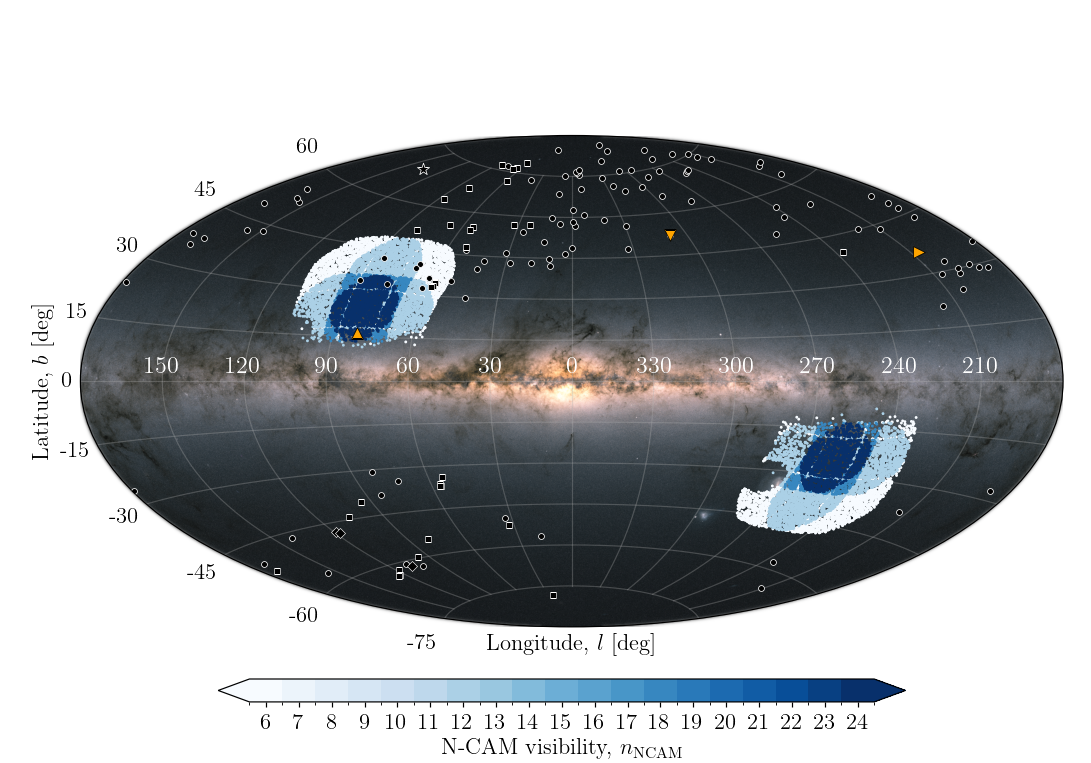

In [219]:
fig, ax = plt.subplots(figsize=(10,7))
axes = fig.add_subplot(111, projection='aitoff', facecolor='none')

s  = 10 
ms = 0.8
fs = 15
lw = 0.5
ec = 'w'
cmap = 'Purples'

# Plot Gaia image
skymap = plt.imread(f'{os.getenv("PLATO_PROJECT_HOME")}/docs/figures/gaiaDR3.png')
ax.imshow(skymap)

# Fetch custom discrete colorbar used by matplotlib
column = dt.ncam
cbins = np.arange(column.min(), column.max()+2, 1) 
ticks = cbins - 0.5
norm  = pt.discretizeColorbar(cbins=cbins, cmap='Blues')
gal = SkyCoord(dt.ra, dt.dec, frame='icrs', unit=u.deg).galactic
im = plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c=column, s=ms, cmap='Blues', norm=norm, zorder=3)

# Plot CRTS candidates
dx = dc[dc.ref == 'crts']
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='o', s=15, ec=ec, lw=lw, zorder=3)

# Plot PTF candidates
dx = dc[dc.ref == 'ptf']
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='s', s=11, ec=ec, lw=lw-0.1, zorder=3)

# Plot ZTF candidates
dx = dc[dc.ref == 'ztf']
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='D', s=22, ec=ec, lw=lw-0.1, zorder=3)

# Plot PanSTARS1 candidates
dx = dc[dc.ref == 'pan']
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='*', s=70, ec=ec, lw=lw, zorder=3)

# Plot GASP candidates
# dx = dc[dc.ref == 'gasp']
# gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
# plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
#             marker='s', s=11, ec=ec, lw=lw-0.1, zorder=3)

# Official candidates: Spikey
dx = dc[(dc.ref == 'spikey')]
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='orange', 
            marker='^', s=60, ec='k', lw=lw, zorder=3)
dx = dc[(dc.ref == 'OJ287')]
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='orange', 
            marker='>', s=60, ec='k', lw=lw, zorder=3)
dx = dc[(dc.ref == 'PG1302')]
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='orange', 
            marker='v', s=60, ec='k', lw=lw, zorder=3)

# Colorbar
cbarax = fig.add_axes([0.2, 0.08, 0.63, 0.03])
cbar = plt.colorbar(im, orientation='horizontal', cax=cbarax, extend='both', 
                    ticks=ticks, boundaries=cbins, format='%1i')
cbar.set_label(r'N-CAM visibility, $n_{\rm NCAM}$', fontsize=fs) 
cbar.ax.tick_params(labelsize=fs)

# Change the tick labels so that they are 0->360, rather than -180->+180
tickLabels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])
tickLabels = np.remainder(tickLabels+360, 360)
axes.set_xticklabels(tickLabels)

# Change y ticks and remove last to make space for title
tickLabels = np.array([-75, -60, -45, -30, -15, 0, 15, 30, 45, 60, ''])
axes.set_yticklabels(tickLabels)
axes.tick_params(axis='x', colors='w')

# Increase x and y tick labels
axes.xaxis.set_tick_params(labelsize=fs+1)
axes.yaxis.set_tick_params(labelsize=fs)

# Add axes labels
axes.set_xlabel(r'Longitude, $l$ [deg]', fontsize=fs)
axes.set_ylabel(r'Latitude, $b$ [deg]', fontsize=fs)

# Set grid and remore outer ticks (if set by default)
axes.grid(True, alpha=0.3)
ax.axis('off')
plt.draw()
plt.tight_layout()

# Save figure
# fig.savefig(f'{fdir}/aitoff_plato_candidates.png', bbox_inches='tight', dpi=300)

In [ ]:
# 
dx = dt
dx = dx.sort_values(by=['Pmag'], ascending=False)

In [ ]:
fig, ax = pt.plotPlatoFOV('LOPN1', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=40, lw=0.,
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPN1', horizontalalignment='center', verticalalignment='center', fontsize=20)
fig.savefig(f'{fdir}/skymap_quasars_LOPN1.png', bbox_inches='tight', dpi=300)

In [ ]:
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=40, lw=0.0,
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPS2', horizontalalignment='center', verticalalignment='center', fontsize=20)
fig.savefig(f'{fdir}/skymap_quasars_LOPS2.png', bbox_inches='tight', dpi=200)

### *Limiting magnitude*

In [ ]:
dx = dt

In [ ]:
dx[(dx.b < 0) & (dx.Pmag < 17.5)].shape[0], dx[(dx.b > 0) & (dx.Pmag < 17.5)].shape[0]

In [ ]:
dx[(dx.b < 0) & (dx.Pmag < 17)].shape[0], dx[(dx.b > 0) & (dx.Pmag < 17)].shape[0]

In [ ]:
dx = dx[dx.Pmag < 17]
dx = dx.sort_values(by=['Pmag'], ascending=False)

In [ ]:
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=100, lw=0.3,
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPS2', horizontalalignment='center', verticalalignment='center', fontsize=20)
fig.savefig(fdir / 'skymap_quasars_LOPS2_mag17.png', bbox_inches='tight', dpi=300)

In [ ]:
lop = 'LOPN1'
fig, ax = pt.plotPlatoFOV(lop, system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=100, lw=0.2,
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, lop, horizontalalignment='center', verticalalignment='center', fontsize=20)
fig.savefig(fdir / f'skymap_quasars_{lop}_mag17.png', bbox_inches='tight', dpi=300)